In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "pyproject.toml").is_file():
    project_root = project_root.parent
if not (project_root / "pyproject.toml").is_file():
    raise FileNotFoundError("Could not find the ExtractSubtitles project root")

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import tesseract_hebrew_utils
import tesseract_sql
from paths import CANONICAL_DATABASE_PATH, SCHEMA_PATH
from utils import pre_process_images, transform_ecc


## Experiment provenance

This notebook uses the canonical project database and schema resolved from the project root.
The distance matrix is an exploratory cache, not a production input.

- Database: `letters.sqlite`
- Schema: `resources/letters.sql`
- Letter: `כ`
- Preprocessing: grayscale, 10-pixel border, inversion, 2x enlargement, threshold-to-zero at 64, and Gaussian blur `(9, 9)` with sigma 10
- Merge threshold: correlation greater than `0.94`
- Dismissal threshold: correlation below `0.7`
- Matrix file: `distance_matrix_כ.npy`

The matrix should be regenerated if the database, preprocessing steps, or thresholds change.

In [3]:
def disp(image):
    display(Image.fromarray(image))

In [ ]:
letter = 'כ'

matrix_path = project_root / f'distance_matrix_{letter}.npy'
if not matrix_path.is_file():
    raise FileNotFoundError(
        f"Distance matrix not found: {matrix_path}. "
        "Run the matrix-generation experiment before this analysis."
    )

distance_matrix = np.load(matrix_path)
print(f"Loaded {matrix_path}")
print(distance_matrix)
display(distance_matrix)


[[1.                nan        nan ...        nan        nan        nan]
 [       nan 1.         0.9650075  ... 0.9637221  0.95854384 0.962921  ]
 [       nan 0.9650075  1.         ... 0.9617121  0.976656   0.9697253 ]
 ...
 [       nan 0.9637221  0.9617121  ... 1.         0.9519012  0.96861327]
 [       nan 0.95854384 0.976656   ... 0.9519012  1.         0.9747864 ]
 [       nan 0.962921   0.9697253  ... 0.96861327 0.9747864  1.        ]]


array([[1.        ,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan, 1.        , 0.9650075 , ..., 0.9637221 , 0.95854384,
        0.962921  ],
       [       nan, 0.9650075 , 1.        , ..., 0.9617121 , 0.976656  ,
        0.9697253 ],
       ...,
       [       nan, 0.9637221 , 0.9617121 , ..., 1.        , 0.9519012 ,
        0.96861327],
       [       nan, 0.95854384, 0.976656  , ..., 0.9519012 , 1.        ,
        0.9747864 ],
       [       nan, 0.962921  , 0.9697253 , ..., 0.96861327, 0.9747864 ,
        1.        ]], dtype=float32)

In [5]:
#distance_matrix.reshape(distance_matrix.shape[0]*distance_matrix.shape[1])
values = pd.DataFrame(distance_matrix.flatten())

In [6]:
values.describe()

,0
count,9458.000000
mean,0.967205
std,0.013910
min,0.900388
25%,0.960753
50%,0.969940
75%,0.976260
max,1.000000


array([[<AxesSubplot:title={'center':'0'}>]], dtype=object)

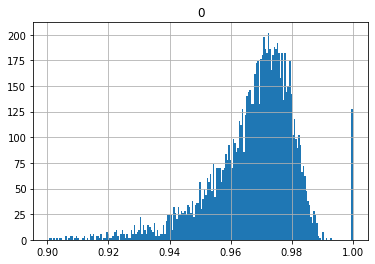

In [7]:
values.hist(bins=200)

In [8]:
dist_df = pd.DataFrame(distance_matrix)
dist_df.idxmin(skipna=True,axis='columns')
x = dist_df.idxmin(skipna=True,axis='columns').reset_index().values.tolist()
idx_tup = [tuple(y) for y in x]

In [9]:
for i in idx_tup: 
    print (i, dist_df.loc[i])

(0, 0) 1.0
(1, 122) 0.9305156
(2, 11) 0.943188
(3, 29) 0.90411246
(4, 82) 0.9697514
(5, 58) 0.9302802
(6, 58) 0.9294066
(7, 122) 0.9428019
(8, 57) 0.9404865
(9, 11) 0.93934333
(10, 58) 0.91617525
(11, 80) 0.9082967
(12, 57) 0.9003883
(13, 57) 0.9378775
(14, 57) 0.9263004
(15, 122) 0.92229825
(16, 11) 0.93029416
(17, 58) 0.93778574
(18, 122) 0.93015707
(19, 111) 0.948706
(20, 20) 1.0
(21, 58) 0.9151377
(22, 11) 0.9459057
(23, 58) 0.9396848
(24, 111) 0.90761375
(25, 57) 0.9276005
(26, 58) 0.94649327
(27, 11) 0.93932116
(28, 58) 0.94186336
(29, 3) 0.90411246
(30, 30) 1.0
(31, 31) 1.0
(32, 11) 0.94346946
(33, 11) 0.93983907
(34, 11) 0.94888335
(35, 11) 0.948182
(36, 90) 0.9692944
(37, 47) 0.92869765
(38, 11) 0.9456339
(39, 11) 0.9398562
(40, 11) 0.91447324
(41, 11) 0.944006
(42, 58) 0.924792
(43, 43) 1.0
(44, 44) 1.0
(45, 111) 0.90777755
(46, 58) 0.943715
(47, 37) 0.92869765
(48, 58) 0.92071086
(49, 57) 0.9059726
(50, 58) 0.926099
(51, 57) 0.94161904
(52, 52) 1.0
(53, 122) 0.9430737
(54, 1

In [10]:
(row,column) = (11, 80)
column

80

In [ ]:
letter = 'כ'
db = tesseract_sql.DatabaseManager(
    CANONICAL_DATABASE_PATH,
    schema_path=SCHEMA_PATH,
    create_if_missing=False,
)

images_sql_unsorted = db.read_images_by_text_orderby_id(letter)
images_sql = sorted(images_sql_unsorted, key=lambda x: x.image_id, reverse=False)
images = [img.image for img in images_sql]

images_enlarged = pre_process_images(images, 2.0)


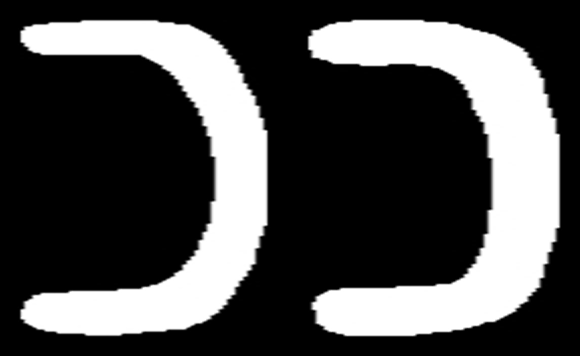

In [13]:
img1 = images_enlarged[row]
img2 = images_enlarged[column]
img3 = images_enlarged[64]

disp(tesseract_hebrew_utils.hconcat_resize_max([img1, img2]))

In [ ]:
cc1, warp_matrix1, warped1 = transform_ecc(img1, img2)
cc2, warp_matrix2, warped2 = transform_ecc(img2, img1)
# Warped is img2 converted to the coordinates of img1


The transform_ECC called 1 times
The transform_ECC called 2 times


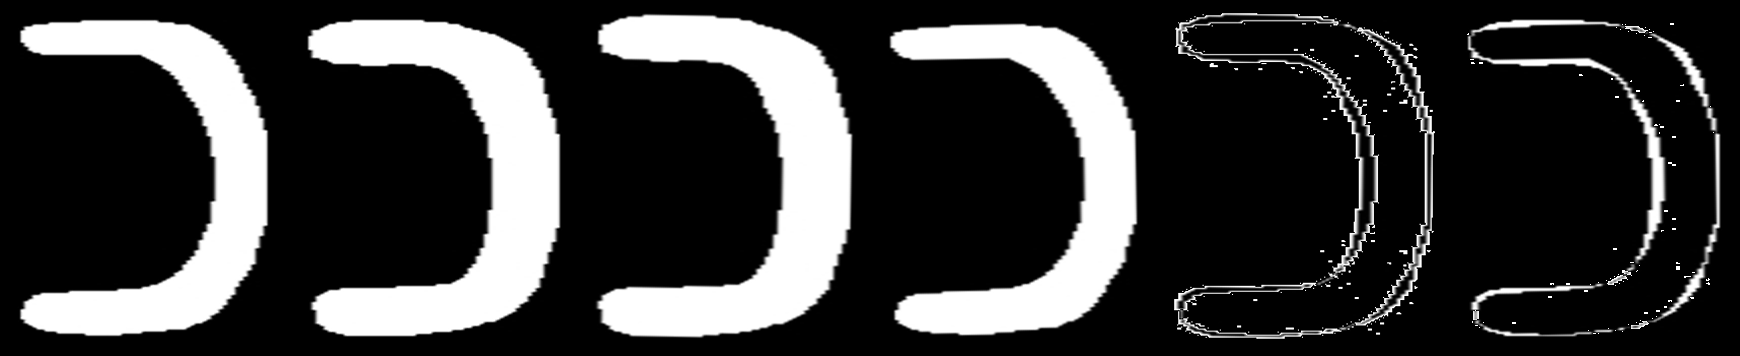

In [16]:
diff1, diff2 = np.abs(img1-warped1),np.abs(img2-warped2)
disp(tesseract_hebrew_utils.hconcat_resize_max([img1, img2,warped1,warped2,diff1, diff2]))

The transform_ECC called 15 times


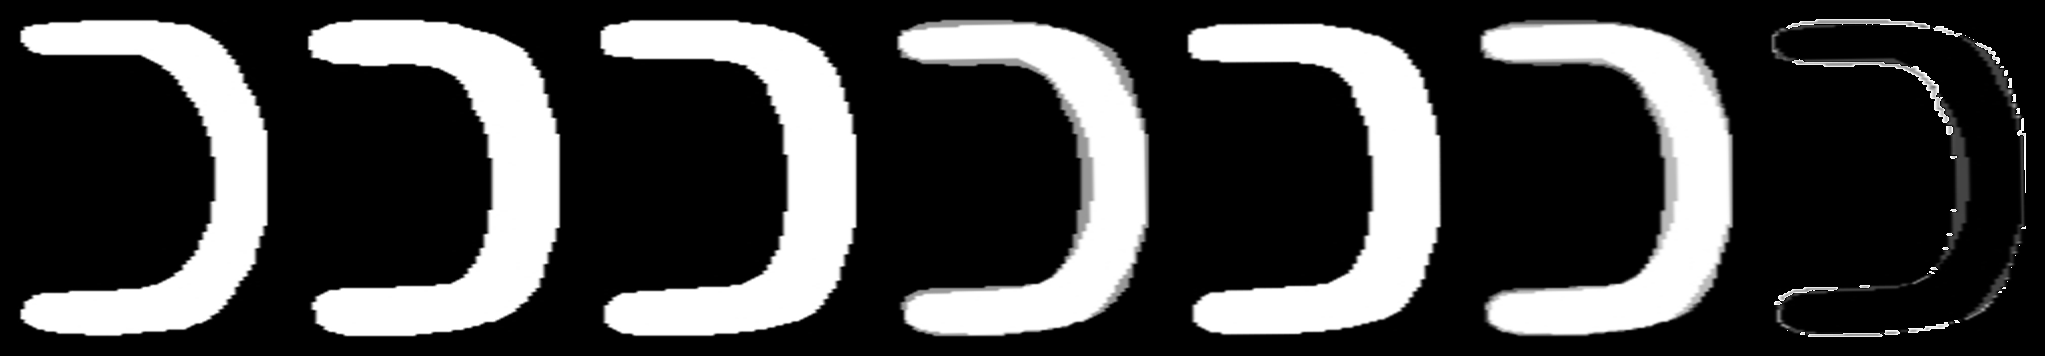

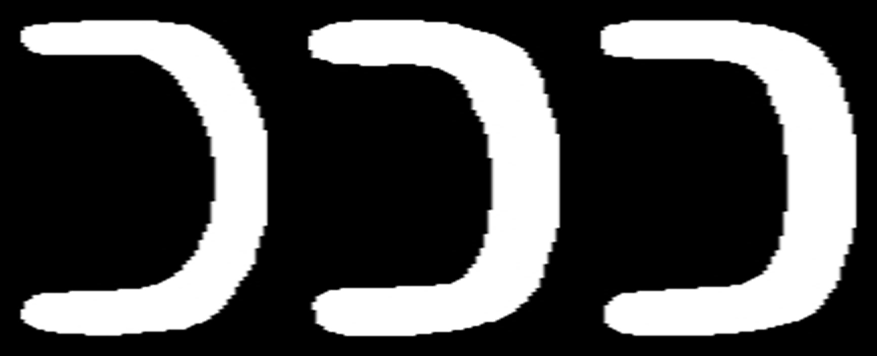

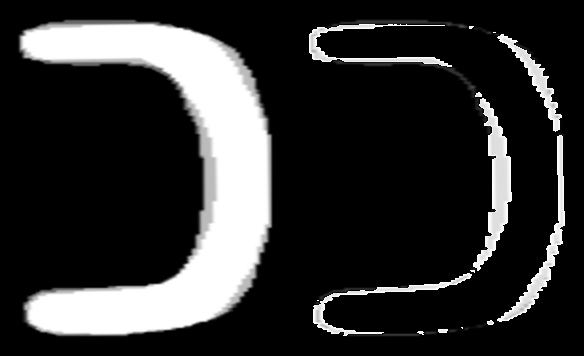

In [ ]:
img1.shape, img2.shape, warped2.shape  # Images may have different original sizes.


def weighted_average(img1, img2, weight1, weight2):
    """Return the weighted pixel average of two same-sized images."""
    all_weight = weight1 + weight2
    img_combined_float = weight1 * img1.astype(np.float64) + (all_weight - weight1) * img2.astype(np.float64)
    img_combined_int = (img_combined_float / all_weight).astype(np.uint8)
    return img_combined_int


interims = []
for pct in np.linspace(0, 1, 11):
    interims.append(weighted_average(img2, warped2, pct, 1.0 - pct))
inter = interims[6]

cc3, warp_matrix3, warped3 = transform_ecc(inter, img3)
new_average = weighted_average(inter, warped3, 2, 1)
disp(tesseract_hebrew_utils.hconcat_resize_max([img1, img2, img3, interims[6], warped3, new_average,
                                                np.abs(warped3 - new_average)]))
disp(tesseract_hebrew_utils.hconcat_resize_max([img1, img2, img3]))
disp(tesseract_hebrew_utils.hconcat_resize_max([new_average, np.abs(inter - new_average)]))


In [166]:
# for i in idx_tup: 
#     print (dist_df.loc[i])

In [ ]:
# Algorithm:
# Init: Every image is its own group with weight 1.0 .
# Pick 2 groups (randomly?). If their representative image is "close", then align and add with respective weights
# If "not close" - cache the distance?
# * Assumption - the distance to one of the images is approximately the distance to its representative?
# In each iteration - try to merge the two largest clusters, unless their distance is already known?
#  Heuristic: Whenever we find a "sample" (image) which is "too far", move to check *it* against all known
#   clusters from the largest.
# Heuristic: If a cluster is larger than half the samples, return it and finish?
# Distance: Sorted dictionary? Key = element with smaller id, value = dicationary {id:dist}




